In [70]:
import geopandas as gpd
import pandas as pd
import sys
import numpy as np
sys.path.append('../src/streaming/3dep')
from get_als import get_nearest_year_product

In [3]:
bbs_surveys = pd.read_parquet('../datasets/BBS/50-StopData_Stop1_wide_commonName.parquet')

In [55]:
def find(row):
    try:
        result = get_nearest_year_product(row['Latitude'], row['Longitude'], 2026)
        assert result is not None, "No product found"
        return result
    except Exception as e:
        return {'product_name_AWS': None, 'collection_year_AWS': None, 'year_diff_AWS': None}

In [ ]:
name_year_yeardiff = bbs_surveys.apply(find, axis=1)
surveys_w_als = bbs_surveys.join(pd.DataFrame.from_records(name_year_yeardiff), how='left')
surveys_w_als = surveys_w_als[surveys_w_als['product_name_AWS'].notna()]

Limit surveys to those within 3 years of the most recent ALS data point

In [79]:
year_difference = surveys_w_als['collection_year_AWS']-surveys_w_als['Year']
surveys_filtered = surveys_w_als[np.abs(year_difference) <= 3]

number of surveys per route:

<Axes: >

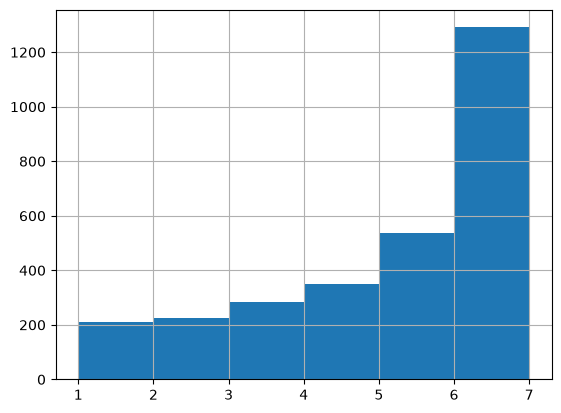

In [80]:
surveys_filtered.groupby(['RouteID']).size().hist(bins=range(1,8))

In [ ]:
surveys_filtered = surveys_filtered.drop(columns=['year_diff_AWS'])
# move Latitude, Longitude, product_name_AWS, collection_year_AWS to beginning
early_cols = surveys_filtered.columns[:3].tolist()+surveys_filtered.columns[-4:].tolist()
other_cols = surveys_filtered.columns[3:-4].tolist()
surveys_filtered = surveys_filtered[early_cols + other_cols]

,RouteID,RouteDataID,Year,Latitude,Longitude,product_name_AWS,collection_year_AWS,Western Grebe,Clark's Grebe,Red-necked Grebe,...,Mountain Bluebird,Scaly-breasted Munia,Muscovy Duck,Sinaloa Wren,Pin-tailed Whydah,Egyptian Goose,Purple Swamphen,Eurasian Collared-Dove,Nanday Parakeet,Yellow-chevroned Parakeet
12308,124_76_190,6351402,2013,45.320950,-70.900470,NH_Umbagog_2016,2016.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12309,124_76_190,6355222,2014,45.320950,-70.900470,NH_Umbagog_2016,2016.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12310,124_76_190,6358259,2015,45.320950,-70.900470,NH_Umbagog_2016,2016.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12311,124_76_190,6362274,2016,45.320950,-70.900470,NH_Umbagog_2016,2016.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12312,124_76_190,6368907,2018,45.320950,-70.900470,NH_Umbagog_2016,2016.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86489,840_92_901,6385759,2023,44.767893,-110.455358,WY_YellowstoneNP_2_2020,2020.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
86497,840_92_902,6365037,2017,42.245683,-106.579149,WY_SouthCentral_2_2020,2020.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
86498,840_92_902,6376336,2021,42.245683,-106.579149,WY_SouthCentral_2_2020,2020.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
86499,840_92_902,6377946,2022,42.245683,-106.579149,WY_SouthCentral_2_2020,2020.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [88]:
# train test split on RouteID
unique_routes = surveys_filtered['RouteID'].unique()
np.random.seed(20260909)
test_routes = np.random.choice(unique_routes, size=int(len(unique_routes)*0.5), replace=False)
surveys_filtered['test_split']=surveys_filtered['RouteID'].isin(test_routes)
surveys_filtered['test_split'].value_counts()

test_split
False    6721
True     6719
Name: count, dtype: int64

In [90]:
len(test_routes), len(unique_routes)-len(test_routes)

(1449, 1449)

In [89]:
surveys_filtered.to_parquet('../datasets/BBS/BBS_train_test.parquet', index=False)